## Objective
Analyze how market sentiment (Fear vs Greed) impacts trader behavior and performance, and identify actionable patterns.

## Data Loading

We load two datasets:
- Market sentiment (Fear/Greed index)
- Historical trader data from Hyperliquid

In [27]:
# load datasets
sentiment = pd.read_csv('../data/sentiment.csv')
trades = pd.read_csv('../data/trades.csv')

display(sentiment.head())
display(trades.head())

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


## Data Inspection

We examine data types, structure, and check for missing values.

In [28]:
sentiment.info()
trades.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-nu

## Data Cleaning & Preprocessing

We convert date columns to proper datetime format and align both datasets on a daily level for analysis.

In [ ]:
# convert sentiment date
sentiment['date'] = pd.to_datetime(sentiment['date'])

# fix trades timestamp (IMPORTANT FIX)
trades['Timestamp IST'] = pd.to_datetime(trades['Timestamp IST'], dayfirst=True)

# align both datasets on daily granularity
trades['date'] = trades['Timestamp IST'].dt.date
trades['date'] = pd.to_datetime(trades['date'])

# check
trades[['Timestamp IST', 'date']].head()

,Timestamp IST,date
0,2024-12-02 22:50:00,2024-12-02
1,2024-12-02 22:50:00,2024-12-02
2,2024-12-02 22:50:00,2024-12-02
3,2024-12-02 22:50:00,2024-12-02
4,2024-12-02 22:50:00,2024-12-02


## Data Merging

We merge trader data with market sentiment using the date column to associate each trade with its corresponding sentiment.

In [33]:
# merge on date
merged = pd.merge(trades, sentiment[['date', 'classification']], on='date', how='left')

# check merge result
merged[['date', 'classification']].head()

# check missing sentiment values (clean output)
int(merged['classification'].isnull().sum())

6

In [34]:
# remove rows with missing sentiment values
merged = merged.dropna(subset=['classification'])

# check remaining missing values
int(merged['classification'].isnull().sum())

0

## Feature Engineering

We compute daily profit and loss (PnL) for each trader and retain market sentiment classification to analyze performance across different market conditions.

In [39]:
# calculate daily PnL per trader (including sentiment)
daily_pnl = merged.groupby(['Account', 'date', 'classification'])['Closed PnL'].sum().reset_index()

# preview
display(daily_pnl.head())

,Account,date,classification,Closed PnL
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,Extreme Greed,0.0
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,Extreme Greed,0.0
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,Extreme Greed,0.0
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,Extreme Greed,-21227.0
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,Extreme Greed,1603.1


## Performance Analysis by Market Sentiment

We analyze how trader profitability varies across different market sentiment conditions.

In [38]:
# average pnl by sentiment
pnl_by_sentiment = daily_pnl.groupby('classification')['Closed PnL'].mean().sort_values()

pnl_by_sentiment

classification
Greed            3318.100730
Neutral          3438.618818
Extreme Fear     4619.439053
Extreme Greed    5161.922644
Fear             5328.818161
Name: Closed PnL, dtype: float64

### Key Insight

Average trader profitability is higher during Fear and Extreme Fear conditions compared to Greed. This suggests that traders perform better in volatile or uncertain market environments than in overly optimistic conditions.

## Visualization: Profitability vs Market Sentiment

We visualize how average trader profitability varies across different market sentiment conditions.

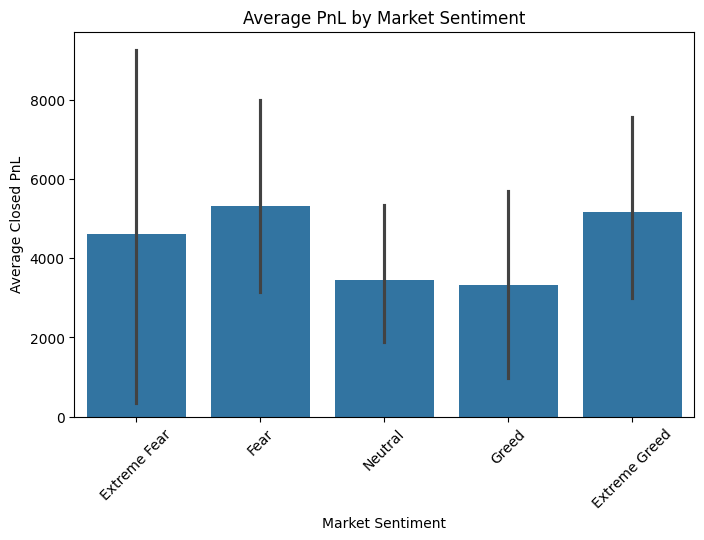

In [42]:
order = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']

plt.figure(figsize=(8,5))
sns.barplot(x='classification', y='Closed PnL', data=daily_pnl, order=order)

plt.xticks(rotation=45)
plt.title("Average PnL by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Closed PnL")

plt.show()

### Insight

Trader profitability peaks during Fear conditions and remains relatively strong in Extreme Fear. Performance declines during Neutral and Greed phases, suggesting that traders may capitalize more effectively during uncertain or volatile market conditions.

## Trading Activity by Market Sentiment

We analyze how trading frequency varies across different market sentiment conditions.

In [ ]:
# trades per day
trades_per_day = merged.groupby(['date', 'classification']).size().reset_index(name='trade_count')

# average trades per sentiment
trades_per_day.groupby('classification')['trade_count'].mean().sort_values()

classification
Greed             260.637306
Extreme Greed     350.807018
Neutral           562.477612
Fear              679.527473
Extreme Fear     1528.571429
Name: trade_count, dtype: float64

### Insight

Trading activity is significantly higher during Fear and Extreme Fear conditions, indicating that traders are more active in volatile or uncertain markets. Activity declines during Greed phases, suggesting reduced trading opportunities or more cautious behavior.

## Trading Behavior: Long vs Short Positions

We analyze how traders position themselves (long vs short) under different market sentiment conditions.

In [43]:
# simplify direction into Long vs Short
merged['position_type'] = merged['Direction'].apply(
    lambda x: 'Long' if 'Long' in x else ('Short' if 'Short' in x else 'Other')
)

# count distribution
direction_dist = merged.groupby(['classification', 'position_type']).size().unstack().fillna(0)

# view
display(direction_dist)

position_type,Long,Other,Short
classification,,,
Extreme Fear,13257,1852,6291
Extreme Greed,13504,12328,14160
Fear,35116,6613,20108
Greed,16581,10735,22987
Neutral,20242,5241,12203


### Insight

Trader positioning shifts with market sentiment. During fearful conditions, traders tend to favor long positions, while during greedy conditions, short positions become more prominent. This suggests behavioral shifts in response to market expectations.

In [20]:
# create win/loss flag
merged['win'] = merged['Closed PnL'] > 0

# win rate per sentiment
win_rate = merged.groupby('classification')['win'].mean()

win_rate

classification
Extreme Fear     0.370607
Extreme Greed    0.464943
Fear             0.420768
Greed            0.384828
Neutral          0.396991
Name: win, dtype: float64

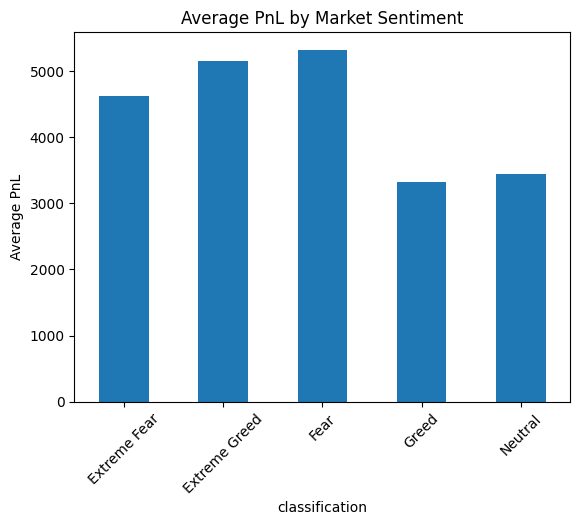

In [21]:
import matplotlib.pyplot as plt

# average pnl by sentiment
pnl_by_sentiment = daily_pnl.groupby('classification')['Closed PnL'].mean()

pnl_by_sentiment.plot(kind='bar')

plt.title("Average PnL by Market Sentiment")
plt.ylabel("Average PnL")
plt.xticks(rotation=45)
plt.show()

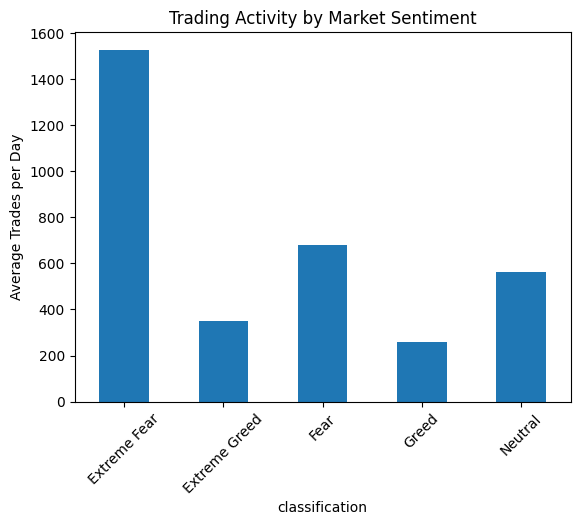

In [22]:
trades_per_day.groupby('classification')['trade_count'].mean().plot(kind='bar')

plt.title("Trading Activity by Market Sentiment")
plt.ylabel("Average Trades per Day")
plt.xticks(rotation=45)
plt.show()

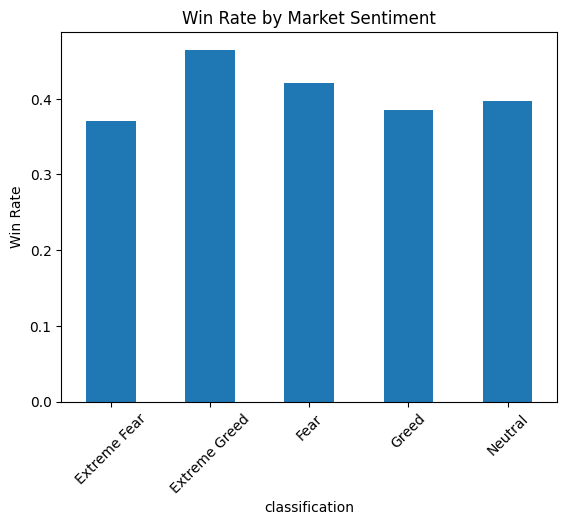

In [23]:
win_rate.plot(kind='bar')

plt.title("Win Rate by Market Sentiment")
plt.ylabel("Win Rate")
plt.xticks(rotation=45)
plt.show()

In [44]:
trader_pnl = merged.groupby('Account')['Closed PnL'].sum()

merged['trader_type'] = merged['Account'].map(
    lambda x: 'winner' if trader_pnl[x] > 0 else 'loser'
)

## Trader Segmentation: Winners vs Losers

In [45]:
merged.groupby(['trader_type', 'classification'])['Closed PnL'].mean()

trader_type  classification
loser        Extreme Fear      -22.598398
             Extreme Greed      51.702381
             Fear               46.768567
             Greed            -202.027754
             Neutral            17.327765
winner       Extreme Fear       37.989084
             Extreme Greed      68.000450
             Fear               54.792435
             Greed              54.444738
             Neutral            35.049780
Name: Closed PnL, dtype: float64

In [52]:
median_size = merged['Size USD'].median()

merged['size_group'] = (merged['Size USD'] > median_size).map({
    True: 'high',
    False: 'low'
})

In [53]:
merged.groupby(['size_group', 'classification'])['Closed PnL'].mean()

size_group  classification
high        Extreme Fear       61.196379
            Extreme Greed     140.570044
            Fear               97.025581
            Greed              84.301244
            Neutral            69.581271
low         Extreme Fear        1.157202
            Extreme Greed       9.628661
            Fear                3.580906
            Greed               3.609685
            Neutral             2.188668
Name: Closed PnL, dtype: float64

### Insight

High position size trades generate significantly higher profits across all market sentiments, while low-size trades contribute minimal returns, indicating that trade size is a key driver of profitability.

In [54]:
merged['sentiment_group'] = merged['classification'].replace({
    'Extreme Fear': 'Fear',
    'Extreme Greed': 'Greed'
})

In [55]:
merged.groupby(['trader_type', 'sentiment_group'])['Closed PnL'].mean()

trader_type  sentiment_group
loser        Fear                30.149398
             Greed             -175.851608
             Neutral             17.327765
winner       Fear                50.453180
             Greed               60.582940
             Neutral             35.049780
Name: Closed PnL, dtype: float64

In [56]:
merged.groupby(['size_group', 'sentiment_group'])['Closed PnL'].mean()

size_group  sentiment_group
high        Fear                87.647166
            Greed              108.033872
            Neutral             69.581271
low         Fear                 2.971356
            Greed                6.387068
            Neutral              2.188668
Name: Closed PnL, dtype: float64

## Key Insights

### 1. Trader Performance Varies Strongly by Skill During Greed Phases
Losing traders incur significant losses during Greed conditions, while winning traders remain consistently profitable across all sentiments. This suggests that overconfidence during bullish market phases leads to poor decision-making among less skilled traders.


### 2. Fear Conditions Encourage More Stable Trading Behavior
Both winning and losing traders show relatively stable and positive performance during Fear conditions. This indicates that traders tend to act more cautiously and make more disciplined decisions in uncertain markets.


### 3. Position Size is a Major Driver of Profitability
High position size trades generate substantially higher profits across all market conditions, while low-size trades contribute minimal returns. This highlights that profitability is driven more by trade size than by trading frequency.


### 4. Market Sentiment Influences Behavior More Than Outcomes for Skilled Traders
While sentiment significantly impacts losing traders (especially during Greed), winning traders maintain consistent performance regardless of market conditions, suggesting stronger strategy discipline.